In this notebook we simulate future stock prices, risk-free rates, 3 year bonds and sharpe ratios from 31 october 2014 to 31 october 2033. We assume that the voatility follows stockastic process (Heston Model). We assume that other 

## Libraries

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import market_stochastic_simulation as mss
import retirement_client as pensioner

# 1. Market Simulation Code

$
\begin{cases}
r_{t+dt} = r_t + \kappa_r (\bar{lt_r} - r_t) dt + \sigma_r \sqrt{dt} Z_t^r\\
SR_{t+dt} = SR_t + \kappa_sr (\bar{lt_sr} - SR_t) dt + \sigma_SR \sqrt{dt} Z_t^SR\\
V_{t+dt} = V_t + \kappa_v (lt_V - V_t) dt + \sigma_V \sqrt{V_t} \sqrt{dt} Z_t^V\\
S_{t+dt} = S_t \times \exp \left( \left( r + \bar{\lambda_0} \sigma_t - \frac{1}{2} \sigma_t^2 \right) dt + \sigma_t \sqrt{dt} Z_t^S \right) \\
\end{cases}
$

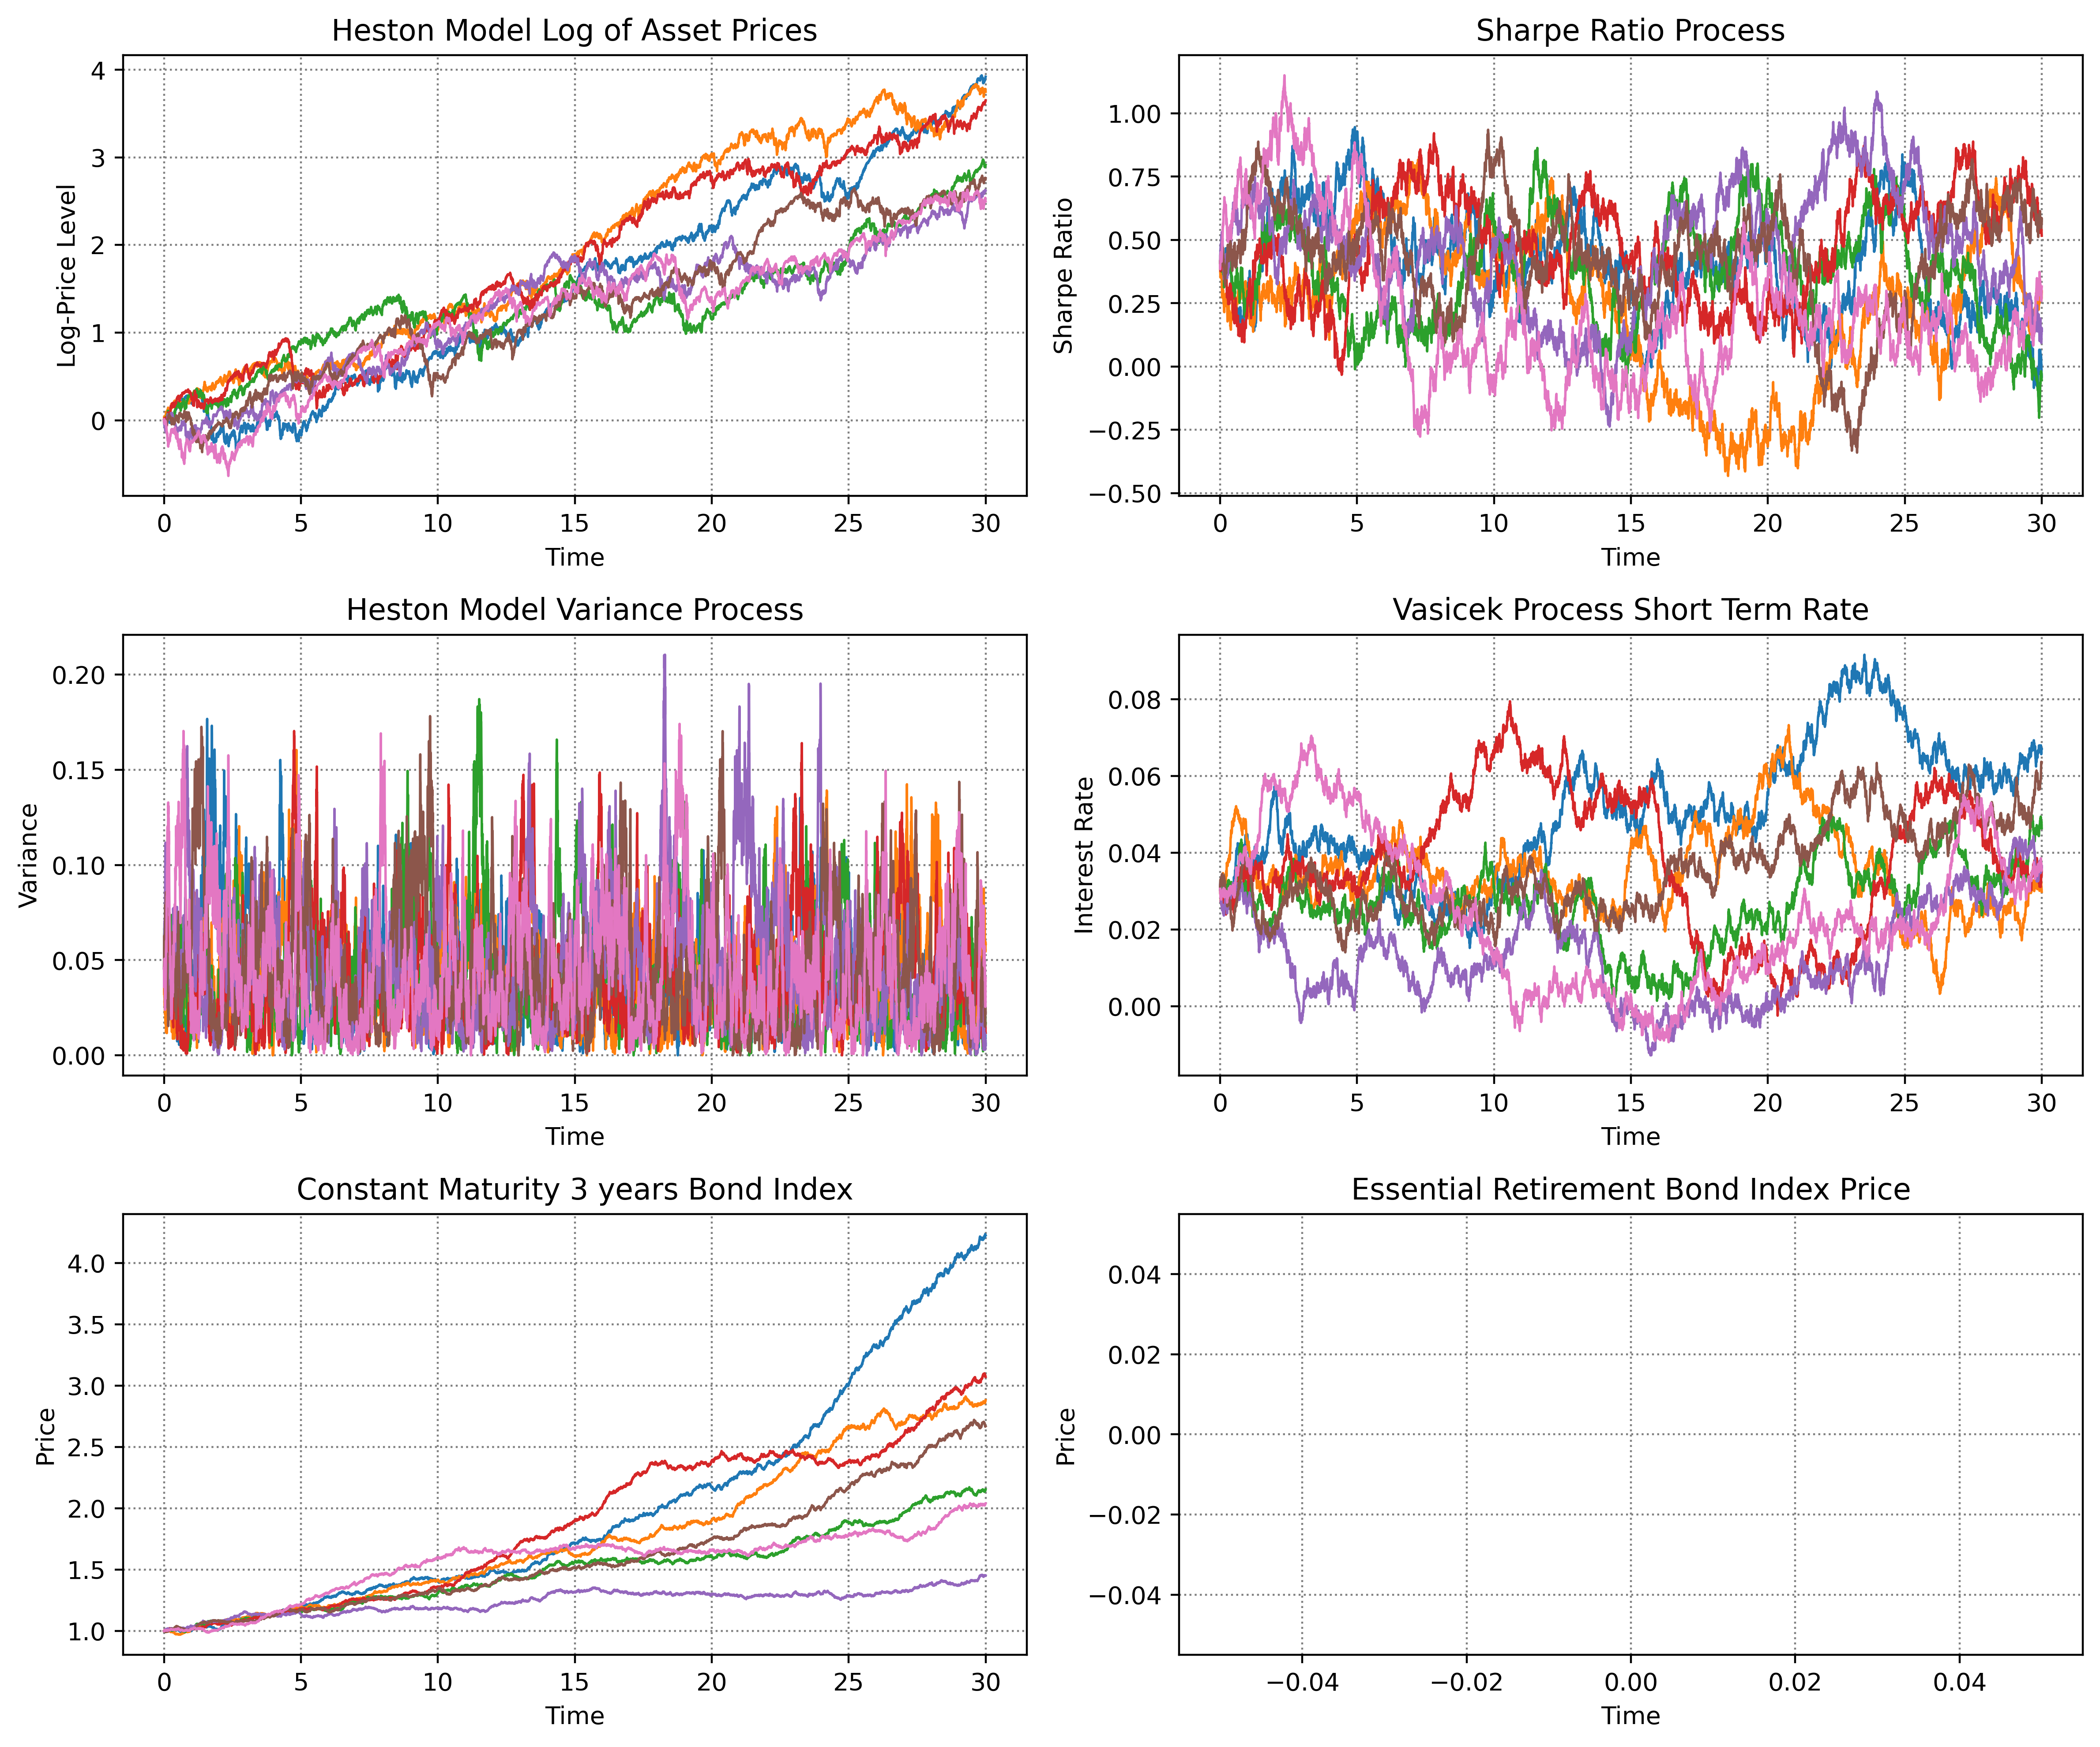

In [13]:
# Parameters
S0 = 1.0              # asset price
T = 30                  # time in years
N = 252*T              # number of time steps in simulation
M = 7                # number of simulated paths
seed = 123              # simulation seed

simulated_market = mss.MarketSimulator(T,N,M,seed, S0)
simulated_market.plot_market_simulation(background_black=False, dpi = 400)

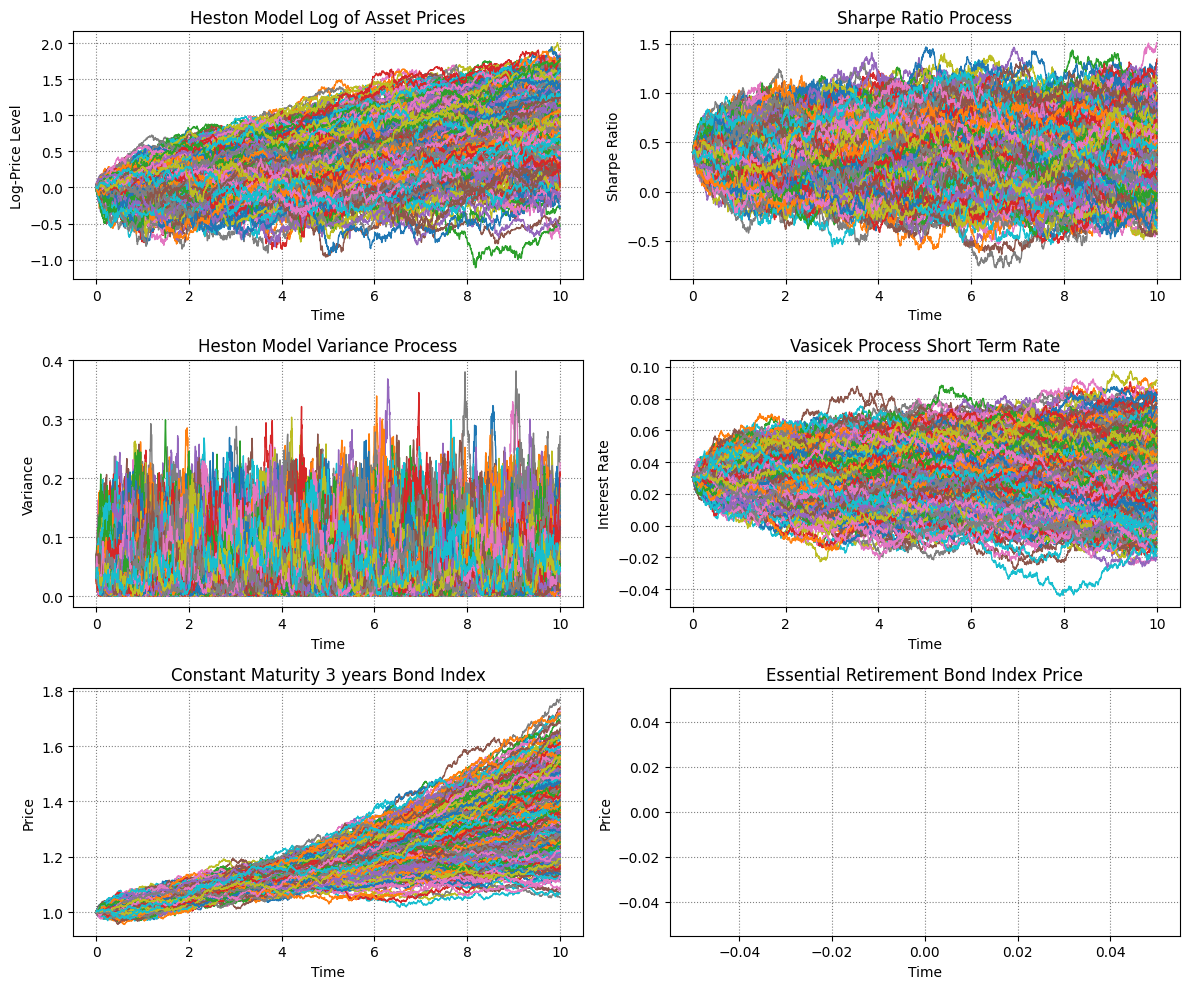

In [14]:
# Parameters
S0 = 1.0              # asset price
T = 10                  # time in years
N = 252*T              # number of time steps in simulation
M = 1000                # number of simulated paths
seed = 123              # simulation seed

simulated_market = mss.MarketSimulator(T,N,M,seed, S0)
simulated_market.plot_market_simulation(background_black=False, dpi = 100)

## Initialize client

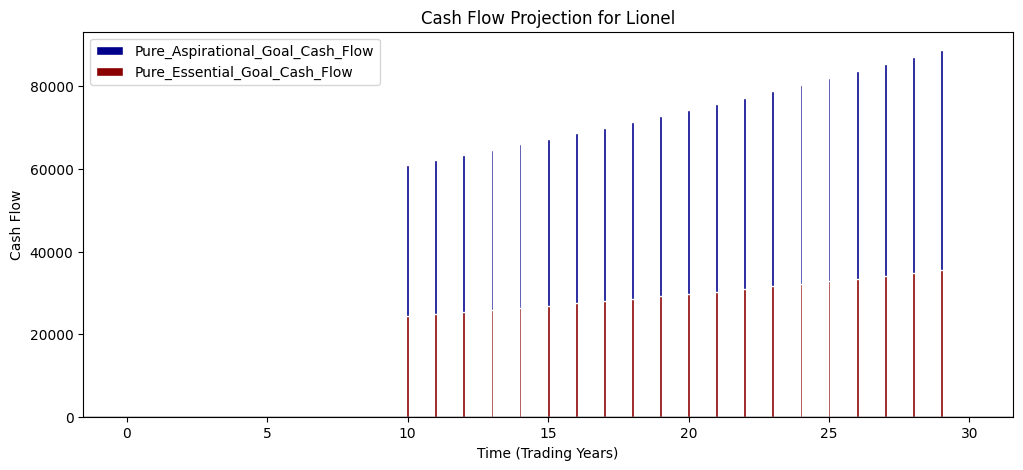

In [15]:
client = pensioner.RetirementClient("Lionel",
                           accumulation_years=10,
                           accumulation_cash_flow=0,
                           decumulation_years=20,
                           decumulation_cash_flow_essential=20000,
                           decumulation_cash_flow_aspirational=50000,
                           periodicity = 12,
                           inflation_rate = 0.02
                           )

client.plot_cash_flows()

In [16]:
df = client.cash_flows_df.loc[:,['Pure_Essential_Goal_Cash_Flow','Pure_Aspirational_Goal_Cash_Flow']]
df = df[df.Pure_Essential_Goal_Cash_Flow!=0]
#for i in np.arange(0,11,1):
#    df.loc[i,:] = 0
df = df.sort_index()

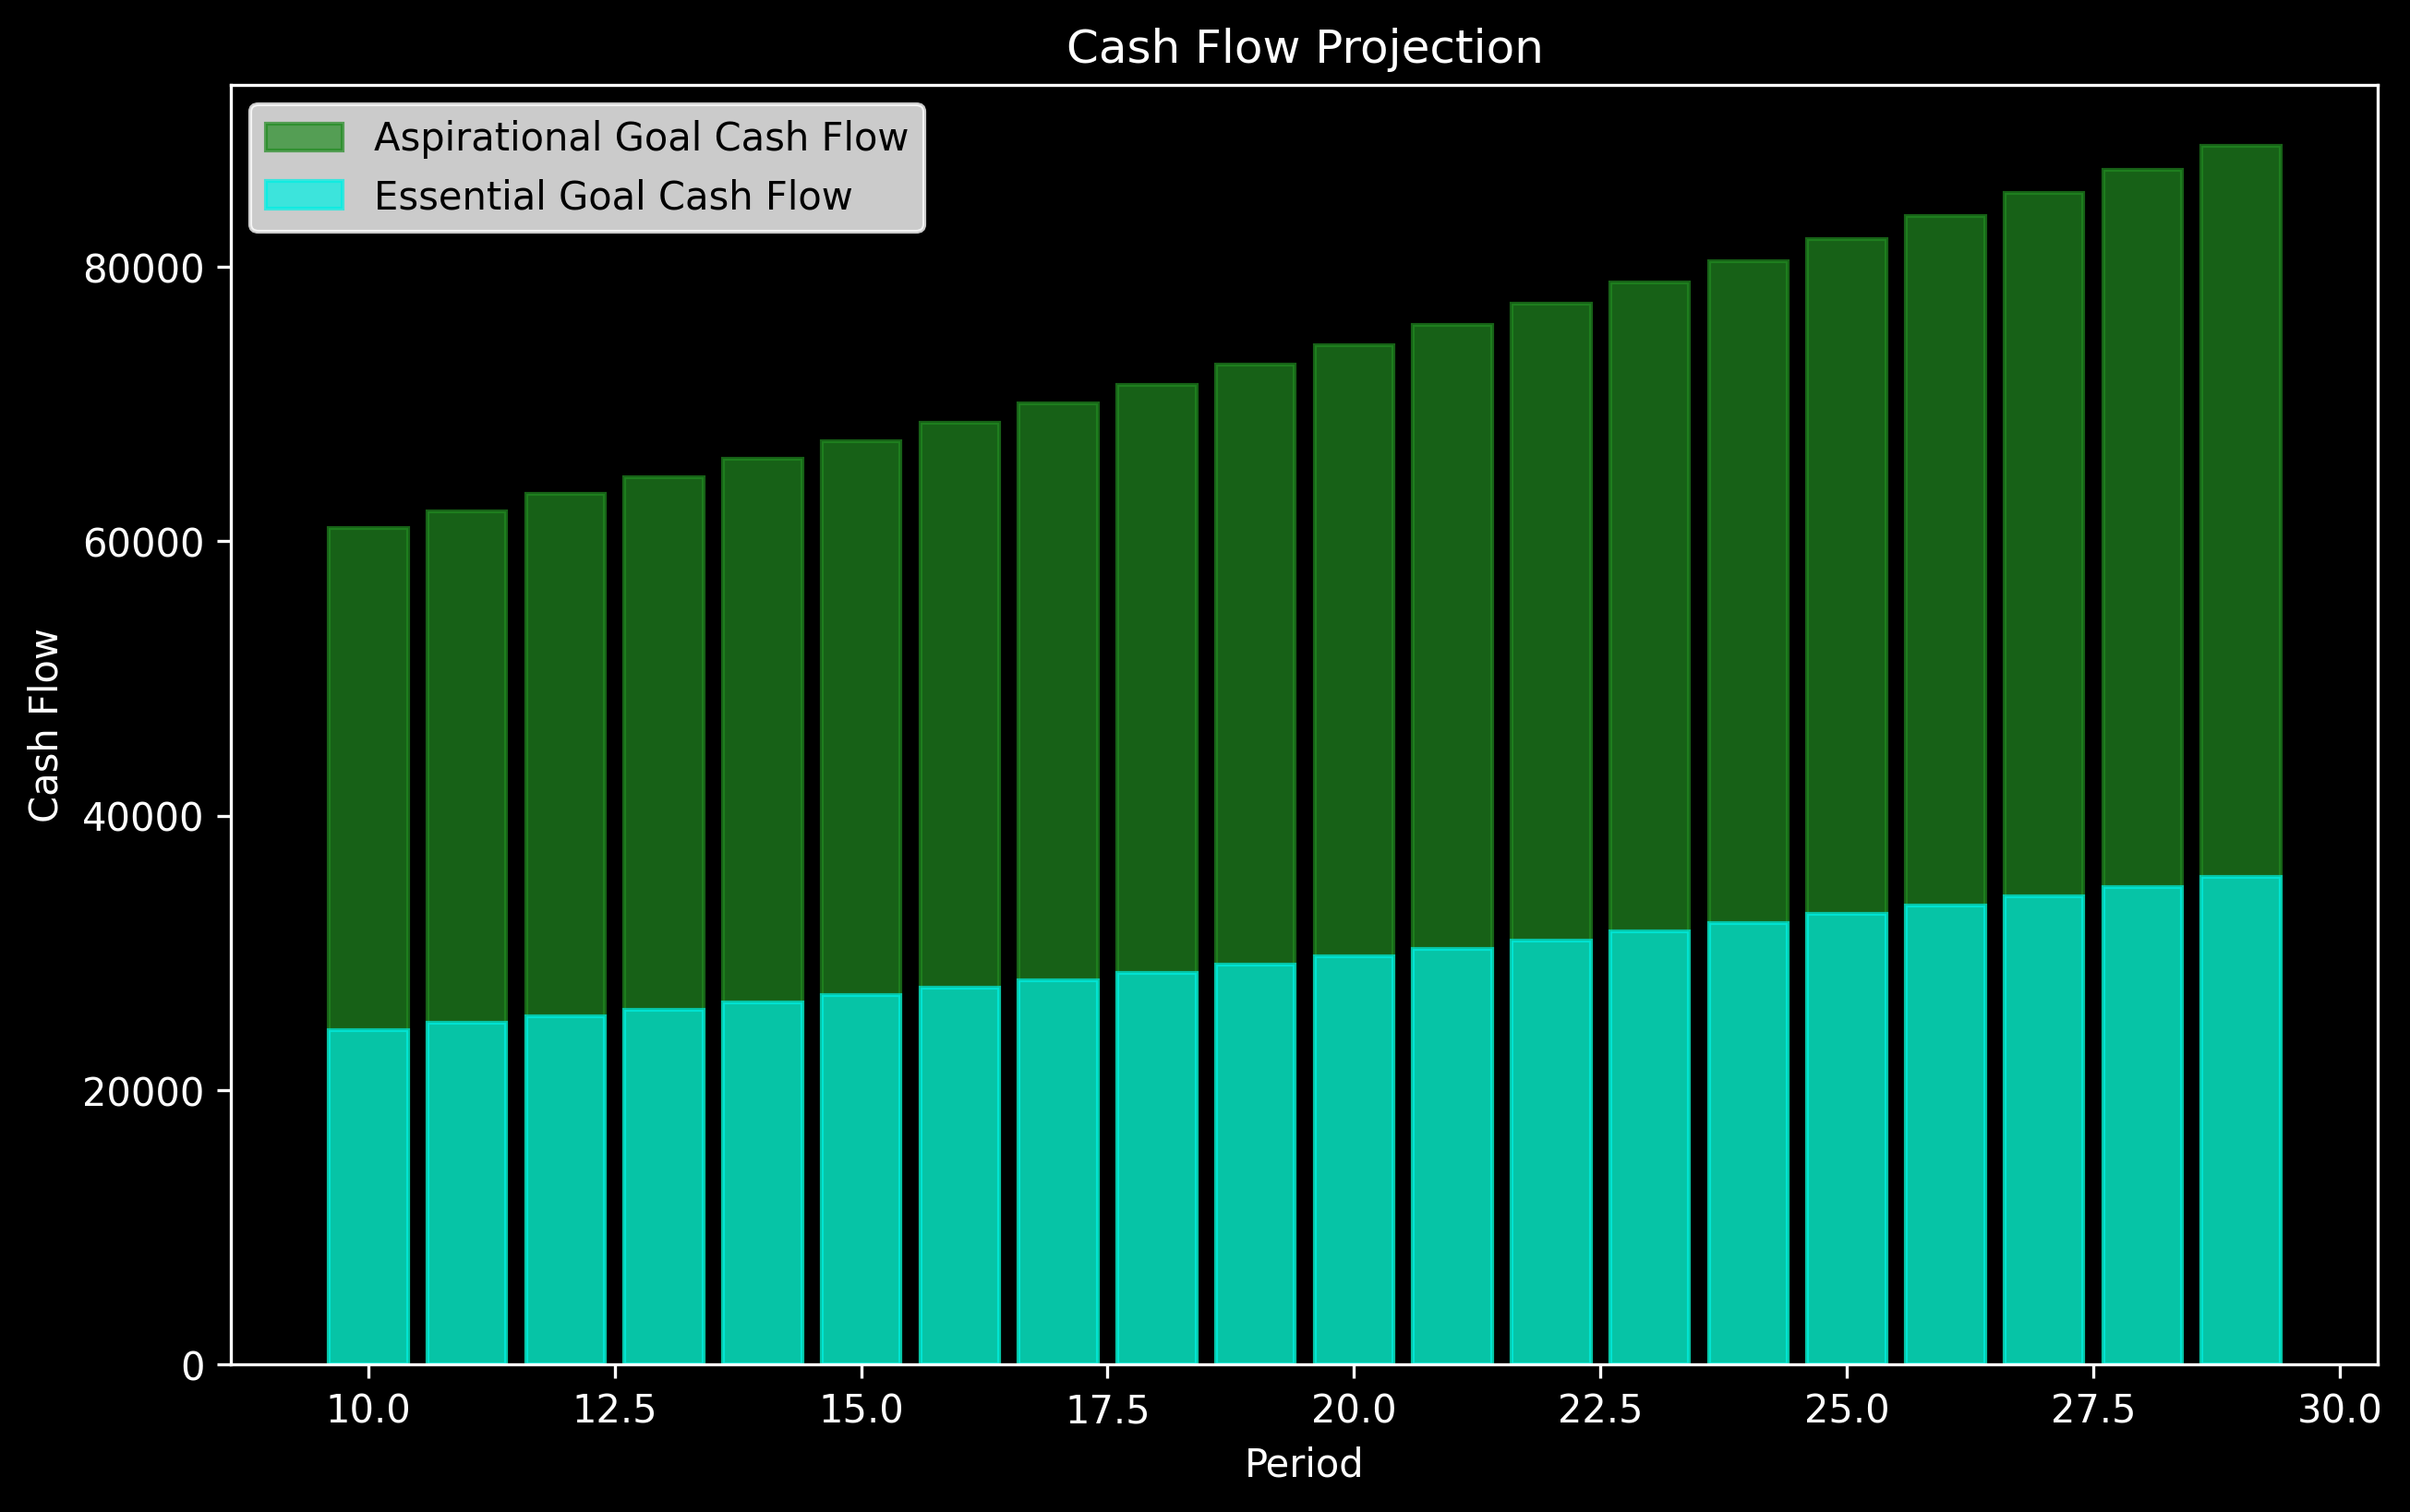

In [53]:
# Extract relevant columns
x_values = df.index  # Time (Period)
y1_values = df.iloc[:, 0]  # Pure_Essential_Goal_Cash_Flow
y2_values = df.iloc[:, 1]  # Pure_Aspirational_Goal_Cash_Flow

# Define colors
background_color = "black"
bar_color_essential = "#00EFE4"  # Sword-like blue
bar_color_aspirational = (34/255, 139/255, 34/255)

# Create the figure
fig, ax = plt.subplots(figsize=(10, 6), dpi = 300)
fig.patch.set_facecolor(background_color)  # Set background

# Plot bars
ax.bar(x_values, y2_values, color=bar_color_aspirational, label="Aspirational Goal Cash Flow", alpha=0.7, edgecolor = bar_color_aspirational)
ax.bar(x_values, y1_values, color=bar_color_essential, label="Essential Goal Cash Flow", edgecolor = bar_color_essential, alpha = 0.7)


# Customizations
ax.set_facecolor(background_color)
ax.spines["bottom"].set_color("white")
ax.spines["top"].set_color("white")
ax.spines["right"].set_color("white")
ax.spines["left"].set_color("white")
ax.tick_params(colors="white")
ax.set_xlabel("Period", color="white")
ax.set_ylabel("Cash Flow", color="white")
ax.set_title("Cash Flow Projection", color="white")
ax.legend(facecolor="white", edgecolor="white")

# Show plot
plt.show()


Now we know cash flows that the client needs. Hence, we can simulate perfect retirement bond for him

In [22]:
simulated_market.calculate_perfect_retirement_bond(client)

Simulating scenarios: 100%|█████████████████| 1000/1000 [03:42<00:00,  4.50it/s]
/Users/aleksandrmikhailov/Desktop/GitHub_EDHEC/Retirement solution/Goal-Based-Investing/market_stochastic_simulation.py:305: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  retirement_bond_essential_p.loc[:, simulation_number] = result_essential[i]
/Users/aleksandrmikhailov/Desktop/GitHub_EDHEC/Retirement solution/Goal-Based-Investing/market_stochastic_simulation.py:306: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  retirement_bond_aspirational_p.loc[

Plot the market and the retirement bond index. If you would use M = 31, you would get full retirement bond price with ladder

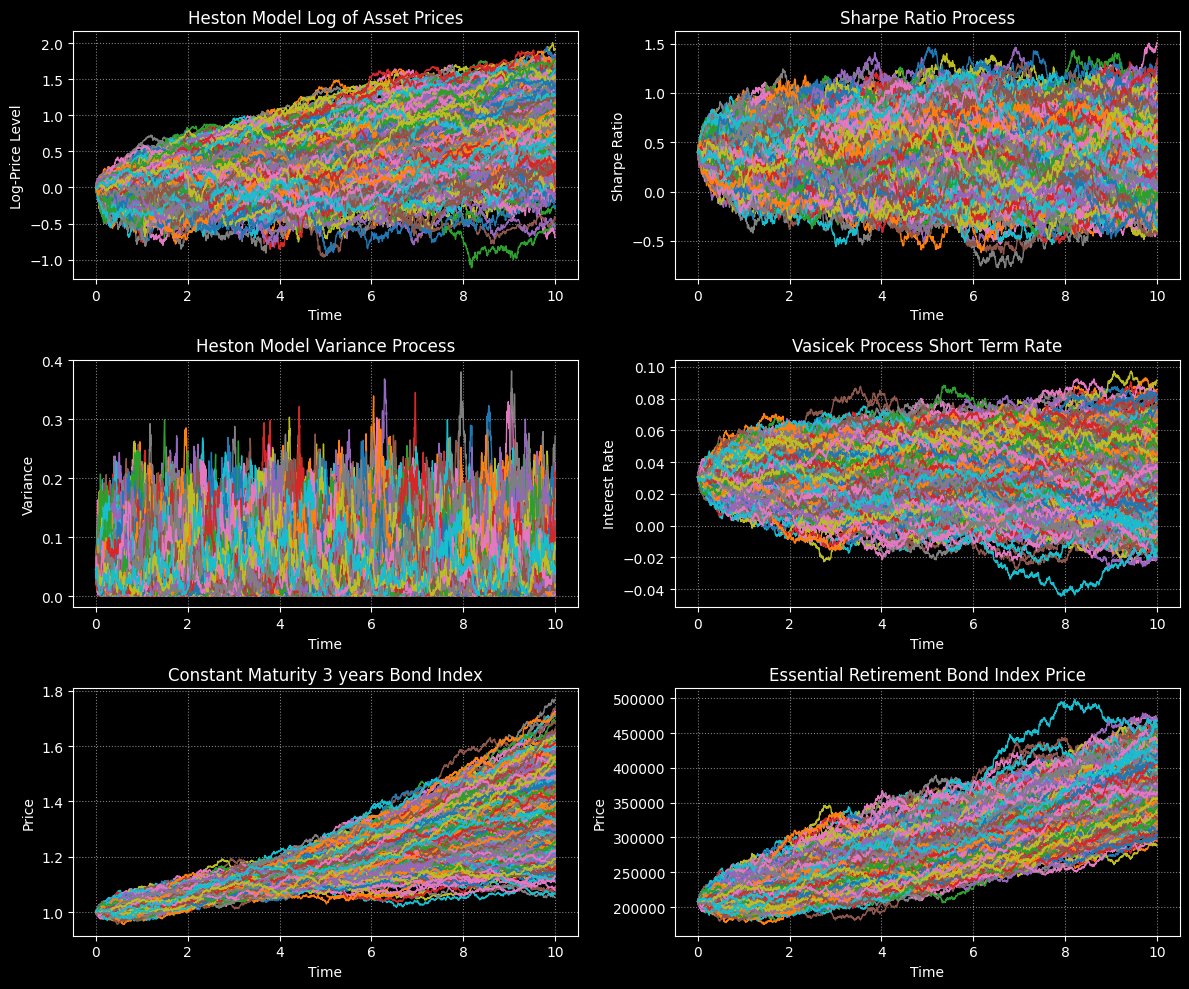

In [23]:
simulated_market.plot_market_simulation()

## Set up a fund

In [24]:
from joblib import Parallel, delayed
class FundAllocationSimulator:
    def __init__(self, initial_savings, retirement_bond_essential_p, retirement_bond_aspirational_p, r_p):
        """
        Initializes the FundAllocationSimulator class with initial savings, 
        retirement bond price data, and short-term interest rates.
        
        Parameters:
        - initial_savings (float): The initial amount invested by the individual.
        - retirement_bond_essential_p (DataFrame): The essential goal retirement bond price data (simulated).
        - retirement_bond_aspirational_p (DataFrame): The aspirational goal bond price data (simulated).
        - r_p (DataFrame): The short-term interest rates for the simulations.
        """
        self.initial_savings = initial_savings
        self.retirement_bond_essential_p = retirement_bond_essential_p
        self.retirement_bond_aspirational_p = retirement_bond_aspirational_p
        self.r_p = r_p
        
        # Calculate the percentage change of the retirement bond price to get RL (Retirement Liability)
        self.RL = self.retirement_bond_aspirational_p.pct_change().fillna(0)

        # Find value of required liabilities (aspirational goal) at period T
        self.RL_AG = self.retirement_bond_aspirational_p.iloc[-1,:]
        
        # Find value of required liabilities (essential goal) at period T
        self.RL_EG = self.retirement_bond_essential_p.iloc[-1,:]

        self.minimal_acceptable_funding_ratio = self.RL_EG / self.RL_AG
        
        # Initialize an empty results DataFrame to store metrics of fund allocation simulations
        self.results_df = pd.DataFrame(columns = ['Probability_Reach_AG',
                                                  'Average_Funding_Ratio_AG',
                                                   'Std_Funding_Ratio_AG',
                                                  'Probability_Reach_EG',
                                                   'Average_Funding_Ratio_EG',
                                                  'Average_Max Drawdown',
                                                   'Average_Tracking_Error'])
                                                    
    def balanced_fund(self, psp_returns, ghp_returns, x, rebalance_each_X_periods,
                      name,
                      periods_per_year):
        """
        Simulates a portfolio with a mix of two assets, PSP and GHP, based on an investment weight x.
        
        Parameters:
        - psp_returns: DataFrame of asset returns (e.g., stock prices).
        - ghp_returns: DataFrame of asset returns (e.g., bond prices: usually retirement bond or constant maturity bond).
        - x: Float (0 <= x <= 1) representing the weight for PSP. The remaining weight is allocated to GHP.
             It does not have restriction to be less than 0 or higher than 1 in code, so maybe this can happen
             If it happens there will be alert raised
        - rebalance_each_X_periods: int or str, Frequency at which to rebalance the portfolio
            If parameter = 2, for instance, rebalancing weill be done every other period (trading days, for instance)
            If parameter = 21, rebalancing will be done every 21st period (every 21st day if we have days)
            If parameter = "no_rebalancing", there is NO REBALANCING. Hence, this is buy and hold strategy
        - name: str. name of the fund
        - periods_per_year: int. Number of periods in investment year
        
        Returns:
        - DataFrame containing the portfolio weights of PSP over time.
        - DataFrame containing the total portfolio returns (of PSP and GHP)
        - DataFrame containing the weight changes for transaction costs
        """
        
        # Step 1: Create a DataFrame to hold the PSP weights in portfolio
        psp_weights = pd.DataFrame(index=psp_returns.index, columns=psp_returns.columns)
        
        # Step 2: Create a DataFrame to hold the portfolio returns over time
        portfolio_returns = pd.DataFrame(index=psp_returns.index, columns=psp_returns.columns)
        
        # Step 3: Create a DataFrame to hold the weight values at rebalancing dates
        weight_change_for_tr_costs_psp = pd.DataFrame(index=psp_returns.index, columns=psp_returns.columns).fillna(0)
        
        # Step 4: Portfolio simulation
        # Weights are initially set to x for PSP
        # All weights for the first time step are based on x (1-x for GHP)
        psp_weights.iloc[0, :] = x
        periods_till_rebalancing = rebalance_each_X_periods
        
        for i in range(1, len(psp_returns)):
            portfolio_returns.iloc[i,:] = psp_weights.iloc[i-1, :] * psp_returns.iloc[i,:] + \
            (1 - psp_weights.iloc[i-1, :]) * ghp_returns.iloc[i,:]
        
            # find new value for PSP and GHP that are based on the returns
            PSP_new_value = psp_weights.iloc[i-1, :] * (1 + psp_returns.iloc[i,:])
            GHP_new_value = (1 - psp_weights.iloc[i-1, :]) * (1 + ghp_returns.iloc[i,:])
            # find total new value of portfolio
            total_portfolio_new_value = PSP_new_value + GHP_new_value
        
            # new drifted weight of PSP is the value of the PSP in total portfolio value
            psp_new_weight = PSP_new_value / total_portfolio_new_value
        
            if rebalance_each_X_periods != "no_rebalancing":
                # if there is rebalancing and it is date of rebalancing today
                periods_till_rebalancing -=1
                if periods_till_rebalancing == 0:
        
                    # then we need to store the change in weights for transaction costs modeling
                    weight_change_for_tr_costs_psp.iloc[i,:] = x - psp_new_weight
        
                    # and put instead of the calculated weights for the new period weights at rebalancing date
                    psp_weights.iloc[i, :] = x
        
                    # reset preiods_till_rebalancing to initial value
                    periods_till_rebalancing = rebalance_each_X_periods
                    
                else:
                    # otherwise, if it is not rabalancing date today just update the weights
                    psp_weights.iloc[i, :] = psp_new_weight
            else:
                # otherwise, if we do not rebalance at all, just update the weights
                psp_weights.iloc[i, :] = psp_new_weight
            
            # Note that in this code return_portfolio = return_assets_t+1*w_t
            # It assures out-of-sample calculation
                
            # Also note that w_t+1 is found using returns of the new period. 
            # It is correct to drift weights like that.
        
            # Finally note that at rebalancing date T there are 2 weights:
            # weight w_T that has drifted from the previous period and 
            # weight w_T = x (initial weight in balanced fund).
            # I save only w_T = x in weights_psp for correctness of portfolio
            # returns calculation
            # I also save x-psp_new_weight to know what was the move for rebalancing: buy / sell and how much
    
        # add entry to results dataframe
        aspirational_funding_ratio, tracking_error = self.add_entry_to_results_dataframe(name,
                                                                 portfolio_returns.fillna(0),
                                                                 periods_per_year = periods_per_year)
        
        # psp_weights will Have no NaN values
        # portfolio_returns will have 1st row of NaNs
        # to find portfolio_returns artificially do psp_weights.shift(1)*psp_return + (1-psp_weights.shift(1))*hgp_return         
        return portfolio_returns.fillna(0), psp_weights, weight_change_for_tr_costs_psp, aspirational_funding_ratio, tracking_error

    def tracking_error(self, fund_returns, periods_in_year):
        """
        Calculate the tracking error between the fund's returns and the retirement liability (RL).
        
        Parameters:
        - fund_returns (DataFrame): The returns of the balanced fund
        
        Returns:
        - tracking_error (float): The tracking error of the portfolio
        """
        return np.std(fund_returns - self.RL) * np.sqrt(periods_in_year)

    def calculate_max_drawdown(self, fund_returns):
        # Compute the cumulative returns
        cumulative_returns = (fund_returns+1).cumprod()-1
    
        # Calculate the running maximum of the cumulative returns
        running_max = cumulative_returns.cummax()
    
        # Calculate the drawdown (percentage decline from the running max)
        drawdown = (cumulative_returns - running_max)
    
        # Calculate the maximum drawdown
        max_drawdown = drawdown.min()
    
        return max_drawdown

    def funding_ratio_utility(self, funding_ratio_AG):
        """
        Evaluates the funding ratio of Aspirational goal based on knowledge about Essential Goal (EG).
    
        Parameters:
        funding_ratio (float): The current funding ratio (relative to Aspirational Goal)
        minimum_acceptable_funding_ratio (float): The Essential Goal funding ratio threshold.
    
        Returns:
        float: -infinity if funding_ratio < minimum_acceptable_funding_ratio, 
        funding_ratio if minimum_acceptable_funding_ratio ≤ funding_ratio ≤ 1, 1 if funding_ratio > 1.
        """
        funding_ratio_AG[funding_ratio_AG<self.minimal_acceptable_funding_ratio] = float('-inf')
        funding_ratio_AG[funding_ratio_AG>1] = 1

        return funding_ratio_AG
        
    def add_entry_to_results_dataframe(self, name_of_portfolio, portfolio_returns, periods_per_year = 252):
        """
        This function creates a new entry in the results dataframe,
        it calculates performance metrics of a given fund and stores the performance
        
        """

        capital_invested = (1+portfolio_returns).cumprod()*self.initial_savings

        # final value of invested capital
        A_T = capital_invested.iloc[-1,:]
        
        self.results_df.loc[name_of_portfolio,'Probability_Reach_AG'] = np.mean(A_T > self.RL_AG).round(3)

        aspirational_funding_ratio = A_T / self.RL_AG
        
        self.results_df.loc[name_of_portfolio,'Average_Funding_Ratio_AG'] = np.mean(aspirational_funding_ratio).round(3)
        
        self.results_df.loc[name_of_portfolio,'Std_Funding_Ratio_AG'] = np.std(A_T / self.RL_AG).round(3)

        self.results_df.loc[name_of_portfolio,'Probability_Reach_EG'] = np.mean(A_T > self.RL_EG).round(3)
        
        self.results_df.loc[name_of_portfolio,'Average_Funding_Ratio_EG'] = np.mean(A_T / self.RL_EG).round(3)
        
        self.results_df.loc[name_of_portfolio,'Breaches_of_EG_per_year'] = np.sum(np.mean(capital_invested <self.retirement_bond_essential_p, axis = 1)\
                                                                                 ) / periods_per_year
        
        self.results_df.loc[name_of_portfolio,'Average_Max Drawdown'] = np.mean(fund_allocation_simulator.calculate_max_drawdown(portfolio_returns)).round(3)

        tracking_error = self.tracking_error(portfolio_returns,periods_per_year)
        
        self.results_df.loc[name_of_portfolio,'Average_Tracking_Error'] = tracking_error.mean().round(3)

        utility_of_funding_ratio = self.funding_ratio_utility(aspirational_funding_ratio.copy())
        self.results_df.loc[name_of_portfolio,'Average_Utility_funding_ratio'] = np.mean(utility_of_funding_ratio)
        #self.results_df.loc[name_of_portfolio,'Std_Utility_funding_ratio'] = np.std(utility_of_funding_ratio)

        return aspirational_funding_ratio, tracking_error

    def draw_funding_ratio_distributions(self, 
                                         name_of_graph, 
                                         funding_ratio_portoflio_1,
                                         funding_ratio_portoflio_2,
                                         funding_ratio_portoflio_3,
                                         tracking_error_1,
                                         tracking_error_2,
                                         tracking_error_3):
        """
        This function creates two side-by-side histograms of funding ratio distributions 
        for three different investment strategies: Aggressive, Moderate, and Defensive.
        
        The function normalizes the histogram frequencies so that they sum up to 1.
        It also includes a vertical dashed line representing the EG Funding Ratio.
    
        Parameters:
        - name_of_graph (str): Title of the graph
        - funding_ratio_portoflio_1: Data for Portfolio 1 (Aggressive)
        - funding_ratio_portoflio_2: Data for Portfolio 2 (Moderate)
        - funding_ratio_portoflio_3: Data for Portfolio 3 (Defensive)
        """
    
        # Create a figure with 1 row and 2 columns (side-by-side plots)
        fig, ax = plt.subplots(1, 2, figsize=(16, 5))
    
        # Define colors, labels, and bin sizes
        colors = ["darkblue", "darkred", "darkgreen"]
        labels = ["Aggressive", "Moderate", "Defensive"]
        bins_list = [30, 20, 10]  # Different bin sizes for each strategy
        
        ####################
        #  Funding ratio   #
        ####################
        # Compute the minimal acceptable funding ratio
        min_funding_ratio_value = self.minimal_acceptable_funding_ratio.iloc[0]
    

        # Iterate over each investment strategy (Aggressive, Moderate, Defensive)
        for i, (portfolio, bins, color, label) in enumerate(zip(
            [funding_ratio_portoflio_3, funding_ratio_portoflio_2, funding_ratio_portoflio_1], 
            bins_list, colors, labels)):
            
            # Compute histogram data
            n, bins = np.histogram(portfolio, bins=bins)
            
            # Normalize so the sum is 1 (relative frequency)
            n = n / n.sum()

            # Plot histogram bars with different colors and labels
            ax[0].bar(bins[:-1], n, width=np.diff(bins), color=color, edgecolor="black", alpha=0.75, label=label)
        
        # Titles and Labels
        ax[0].set_title(name_of_graph+'_Funding_Ratio', fontsize=14, fontweight='bold')
        ax[0].set_xlabel("Terminal Wealth", fontsize=12)
        ax[0].set_ylabel("Normalized Frequency", fontsize=12)

        # Add a vertical dashed line for the minimal acceptable funding ratio
        ax[0].axvline(min_funding_ratio_value, color='darkred', linestyle='--', label='EG Funding Ratio')

        # set xlim
        ax[0].set_xlim(self.minimal_acceptable_funding_ratio[0]*0.6,1.4)
        # Grid for better readability
        ax[0].grid(axis="y", linestyle="--", alpha=0.7)

        # Add legend
        ax[0].legend()

        #####################
        #   Tracking Error  #
        #####################

        # Iterate over each investment strategy (Aggressive, Moderate, Defensive)
        for i, (portfolio, bins, color, label) in enumerate(zip(
            [tracking_error_3,tracking_error_2,tracking_error_1], 
            bins_list, colors, labels)):
            
            # Compute histogram data
            n, bins = np.histogram(portfolio, bins=bins)
            
            # Normalize so the sum is 1 (relative frequency)
            n = n / n.sum()

            # Plot histogram bars with different colors and labels
            ax[1].bar(bins[:-1], n, width=np.diff(bins), color=color, edgecolor="black", alpha=0.75, label=label)
        
        # Titles and Labels
        ax[1].set_title(name_of_graph+'_Tracking_Error', fontsize=14, fontweight='bold')
        ax[1].set_xlabel("Terminal Wealth", fontsize=12)
        ax[1].set_ylabel("Normalized Frequency", fontsize=12)

        # Grid for better readability
        ax[1].grid(axis="y", linestyle="--", alpha=0.7)

        # Add legend
        ax[1].legend()
        
        # Adjust layout and display the figure
        plt.tight_layout()
        plt.show()


    def run_cppi(self,
                 psp_returns,
                 floor,
                 ghp_returns,
                 initial_investment=287000,
                 m=3,
                 n_jobs=-1):  # Use all available CPU cores
        """
        This function runs a Constant Proportion Portfolio Insurance (CPPI) strategy
        using parallel computing to speed up simulations.
    
        Parameters:
        - psp_returns (pd.DataFrame): Matrix of stock returns over time (rows: time, columns: scenarios).
        - floor (pd.DataFrame): Matrix of floor values (minimum acceptable wealth level).
        - ghp_returns: Risk-free fund
        - initial_investment (float): Initial portfolio value (default: 287,000).
        - m (int): Multiplier for allocation to risky assets (default: 3).
        - n_jobs (int): Number of CPU cores to use for parallel execution (-1 = all available cores).
    
        Returns:
        - portfolio (pd.DataFrame): The portfolio value over time for each simulation path.
        """
    
        # Step 2: Define function for parallel execution
        def cppi_simulation(path_index):
            """
            Simulates a single CPPI path.
            Each path follows a strategy based on psp_returns and floor returns.
            """
    
            # Step 2.1: Initialize portfolio and weights
            portfolio_path = pd.Series(index=psp_returns.index)
            weights_path = pd.Series(index=psp_returns.index)
    
            portfolio_path.iloc[0] = initial_investment  # Initial wealth
            weights_path.iloc[0] = m * (initial_investment - floor.iloc[0, path_index]) / initial_investment
    
            # Step 2.2: Iterate over time steps for this path
            previous_time_period = psp_returns.index[0]
            for time_period in psp_returns.index[1:]:
                # Compute CPPI return
                return_cppi = (
                    weights_path.loc[previous_time_period] * psp_returns.loc[time_period, path_index] +
                    (1 - weights_path.loc[previous_time_period]) * ghp_returns.loc[time_period, path_index]
                )
    
                # Update portfolio value
                portfolio_path.loc[time_period] = portfolio_path.loc[previous_time_period] * (1 + return_cppi)
    
                # Update weight for next period
                weights_path.loc[time_period] = m * (portfolio_path.loc[time_period] - floor.loc[time_period, path_index]) / portfolio_path.loc[time_period]
    
                previous_time_period = time_period
    
            return portfolio_path
        
        # Step 3: Run parallel processing for each column (simulation path)
        print("Running CPPI simulations in parallel...")
        results = Parallel(n_jobs=n_jobs)(
            delayed(cppi_simulation)(path_index) for path_index in tqdm(range(psp_returns.shape[1]), desc="Simulating Paths")
        )
        
        # Step 4: Convert results to DataFrame
        portfolio = pd.DataFrame(results).T  # Transpose to match the original format
        
        return portfolio

    def CPPI_basic(self,
                   floor, #= simulated_market.retirement_bond_essential_p,
                   psp_returns, #= simulated_market.S_p.pct_change().fillna(0),
                   ghp_returns, #= simulated_market.retirement_bond_essential_p.pct_change().fillna(0),
                   m = 3,
                   initial_wealth = 287000
                  ):

        """
        floor is PV of essential goal
        m is riskiness of the strategy
        psp_returns and ghp_returns are returns 
        initial wealth is the initial amount of money individual has
        """
        # set up weights for each period
        weights = pd.DataFrame(columns = psp_returns.columns, index = psp_returns.index)
        weights.loc[0,:] = m * (initial_wealth-floor.loc[0,:])/initial_wealth
        
        # set up portfolio 
        portfolio = pd.DataFrame(columns = psp_returns.columns, index = psp_returns.index)
        portfolio.loc[0,:] = initial_wealth
        
        # difference between 2 closes time periods
        previous_time_period = psp_returns.index[0]
        
        # for each time incterement from the 1st to last
        for time_period in tqdm(psp_returns.index[1:]):
            
            # Step 1: find CPPI return & current portfolio value
            return_cppi = weights.loc[previous_time_period,:]*psp_returns.loc[time_period,:] + (1-weights).loc[previous_time_period,:]*ghp_returns.loc[time_period,:]
            
            portfolio.loc[time_period,:] = portfolio.loc[previous_time_period,:] * (1 + return_cppi)
        
            # find weights for the new period
            weights.loc[time_period,:] = m * (portfolio.loc[time_period,:] - floor.loc[time_period,:])/ portfolio.loc[time_period,:]
        
            previous_time_period = time_period
            
        return portfolio

In [25]:
fund_allocation_simulator = FundAllocationSimulator(initial_savings = 287000,
                                                    retirement_bond_essential_p = simulated_market.retirement_bond_essential_p,
                                                    retirement_bond_aspirational_p = simulated_market.retirement_bond_aspirational_p,
                                                    r_p = simulated_market.r_p)

## Buy and Hold Strategy

In [26]:
_, _, _,  aspirational_funding_ratio_bnh0_1, tracking_error_bnh0_1 = fund_allocation_simulator.balanced_fund(psp_returns = simulated_market.S_p.pct_change(),
                                                                                ghp_returns = simulated_market.retirement_bond_aspirational_p.pct_change(),
                                                                                x = 0.1,
                                                                                rebalance_each_X_periods = 'no_rebalancing',
                                                                                name = 'Buy_and_Hold_x_0.1_rebalancing_none',
                                                                                periods_per_year = int(N/T))

_, _, _,  aspirational_funding_ratio_bnh0_2, tracking_error_bnh0_2 =fund_allocation_simulator.balanced_fund(psp_returns = simulated_market.S_p.pct_change(),
                                                                                ghp_returns = simulated_market.retirement_bond_aspirational_p.pct_change(),
                                                                                x = 0.2,
                                                                                rebalance_each_X_periods = 'no_rebalancing',
                                                                                name = 'Buy_and_Hold_x_0.2_rebalancing_none',
                                                                                periods_per_year = int(N/T))

_, _, _,  aspirational_funding_ratio_bnh0_3, tracking_error_bnh0_3= fund_allocation_simulator.balanced_fund(psp_returns = simulated_market.S_p.pct_change(),
                                                                                ghp_returns = simulated_market.retirement_bond_aspirational_p.pct_change(),
                                                                                x = 0.3,
                                                                                rebalance_each_X_periods = 'no_rebalancing',
                                                                                name = 'Buy_and_Hold_x_0.3_rebalancing_none',
                                                                                periods_per_year = int(N/T))

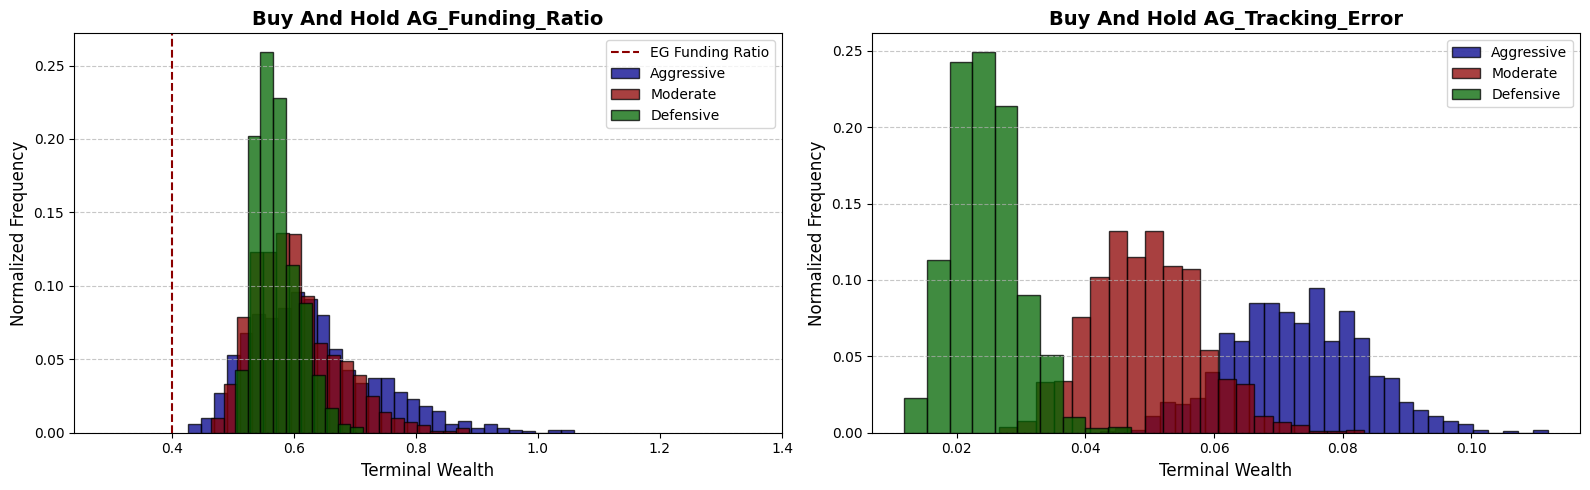

In [27]:
fund_allocation_simulator.draw_funding_ratio_distributions("Buy And Hold AG",
                                                          aspirational_funding_ratio_bnh0_1,
                                                          aspirational_funding_ratio_bnh0_2,
                                                          aspirational_funding_ratio_bnh0_3,
                                                          tracking_error_bnh0_1,
                                                          tracking_error_bnh0_2,
                                                          tracking_error_bnh0_3
                                                          )

Buy and Hold with correct safe asset is a benchmark. Any further strategy should be better than this one. The strategy manages to not breach the EG which is very good

## Buy and Hold with Incorrect safe asset

In [28]:
_, _, _,  aspirational_funding_ratio_bnh0_1, tracking_error_bnh0_1 = fund_allocation_simulator.balanced_fund(psp_returns = simulated_market.S_p.pct_change(),
                                                                                ghp_returns = simulated_market.B_p.pct_change(),
                                                                                x = 0.1,
                                                                                rebalance_each_X_periods = 21,
                                                                                name = 'Buy_and_Hold_x_0.1_no_rebalancing_Constant_Maturity',
                                                                                periods_per_year = int(N/T))

_, _, _,  aspirational_funding_ratio_bnh0_2, tracking_error_bnh0_2 =fund_allocation_simulator.balanced_fund(psp_returns = simulated_market.S_p.pct_change(),
                                                                                ghp_returns = simulated_market.B_p.pct_change(),
                                                                                x = 0.2,
                                                                                rebalance_each_X_periods = 21,
                                                                                name = 'Buy_and_Hold_x_0.2_no_rebalancing_Constant_Maturity',
                                                                                periods_per_year = int(N/T))

_, _, _,  aspirational_funding_ratio_bnh0_3, tracking_error_bnh0_3= fund_allocation_simulator.balanced_fund(psp_returns = simulated_market.S_p.pct_change(),
                                                                                ghp_returns = simulated_market.B_p.pct_change(),
                                                                                x = 0.3,
                                                                                rebalance_each_X_periods = 21,
                                                                                name = 'Buy_and_Hold_x_0.3_no_rebalancing_Constant_Maturity',
                                                                                periods_per_year = int(N/T))

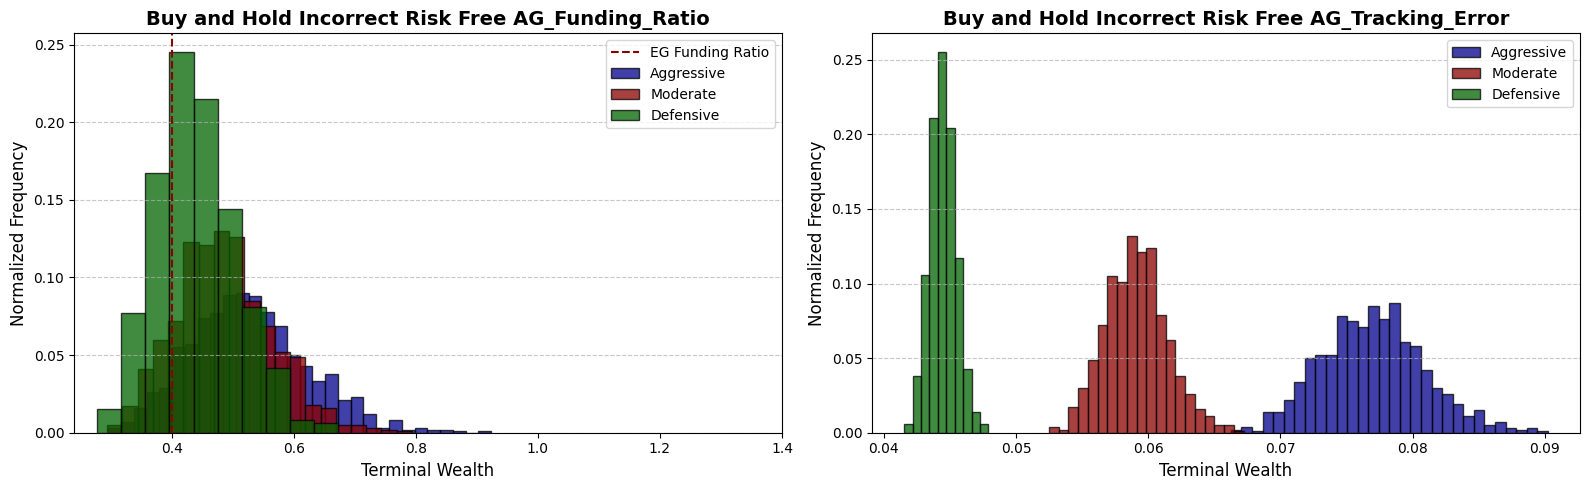

In [29]:
fund_allocation_simulator.draw_funding_ratio_distributions("Buy and Hold Incorrect Risk Free AG",
                                                          aspirational_funding_ratio_bnh0_1,
                                                          aspirational_funding_ratio_bnh0_2,
                                                          aspirational_funding_ratio_bnh0_3,
                                                          tracking_error_bnh0_1,
                                                          tracking_error_bnh0_2,
                                                          tracking_error_bnh0_3
                                                          )

Incorrect safe asset adds a lot of trouble to the strategy. It clearly shows that when retirement bond does not exist it is impossivle to meet obligations with Buy & Hold Strategy

## Optimal Buy and Hold with correct Risk Free

An optimal Buy and Hold strategy would find present value of EG and invest all money needed to reach it in GHP. the rest should be invested in PSP. There is no need for rebalancing in such strategy. It is easy and simple

In [30]:
initial_sum_required_to_meet_EG = fund_allocation_simulator.retirement_bond_essential_p.iloc[0,:]
initial_weight_of_ghp = initial_sum_required_to_meet_EG / fund_allocation_simulator.initial_savings
initial_weight_of_ghp[0]

0.7244411232012404

Our calculations show that meeting essential goal is possible if 72% of initial welath is invested in GHP. Let's do it

In [31]:
_, _, _,  aspirational_funding_ratio_bnh0_1, tracking_error_bnh0_1 = fund_allocation_simulator.balanced_fund(psp_returns = simulated_market.S_p.pct_change(),
                                                                                ghp_returns = simulated_market.retirement_bond_aspirational_p.pct_change(),
                                                                                x = 1-initial_weight_of_ghp[0],
                                                                                rebalance_each_X_periods = 'no_rebalancing',
                                                                                name = 'Buy_and_Hold_Best',
                                                                                periods_per_year = int(N/T))

In [32]:
fund_allocation_simulator.results_df.sort_values(by = 'Average_Funding_Ratio_AG', ascending = False).sort_values(by = 'Probability_Reach_EG', ascending = False)

,Probability_Reach_AG,Average_Funding_Ratio_AG,Std_Funding_Ratio_AG,Probability_Reach_EG,Average_Funding_Ratio_EG,Average_Max Drawdown,Average_Tracking_Error,Breaches_of_EG_per_year,Average_Utility_funding_ratio
Buy_and_Hold_x_0.3_rebalancing_none,0.004,0.642,0.103,1.0,1.604,-0.274,0.074,0.000000,0.641470
Buy_and_Hold_Best,0.002,0.634,0.095,1.0,1.586,-0.253,0.068,0.000000,0.634329
Buy_and_Hold_x_0.2_rebalancing_none,0.0,0.612,0.069,1.0,1.53,-0.191,0.051,0.000000,0.611831
Buy_and_Hold_x_0.1_rebalancing_none,0.0,0.582,0.034,1.0,1.455,-0.133,0.026,0.000000,0.581990
Buy_and_Hold_x_0.3_no_rebalancing_Constant_Maturity,0.0,0.538,0.097,0.936,1.346,-0.193,0.077,0.259401,-inf
Buy_and_Hold_x_0.2_no_rebalancing_Constant_Maturity,0.0,0.498,0.079,0.892,1.245,-0.121,0.059,0.311567,-inf
Buy_and_Hold_x_0.1_no_rebalancing_Constant_Maturity,0.0,0.459,0.066,0.813,1.148,-0.064,0.045,0.513512,-inf


Results show that the "best fund" lost to "Buy_and_Hold_x_0.3". It happened, because in no scenarios stock price went to 0. Also at some point in simulation the 0.3 allocation could have breached EG. In these 1000 simulations it did not, but it is possible

## Balanced Strategy with correct Risk Free

In [33]:
_, _, _,  aspirational_funding_ratio_bnh0_1, tracking_error_bnh0_1 = fund_allocation_simulator.balanced_fund(psp_returns = simulated_market.S_p.pct_change(),
                                                                                ghp_returns = simulated_market.retirement_bond_aspirational_p.pct_change(),
                                                                                x = 0.1,
                                                                                rebalance_each_X_periods = 21,
                                                                                name = 'Balanced_Fund_x_0.1_rebalancing_21',
                                                                                periods_per_year = int(N/T))

_, _, _,  aspirational_funding_ratio_bnh0_2, tracking_error_bnh0_2 =fund_allocation_simulator.balanced_fund(psp_returns = simulated_market.S_p.pct_change(),
                                                                                ghp_returns = simulated_market.retirement_bond_aspirational_p.pct_change(),
                                                                                x = 0.2,
                                                                                rebalance_each_X_periods = 21,
                                                                                name = 'Balanced_Fund_x_0.2_rebalancing_21',
                                                                                periods_per_year = int(N/T))

_, _, _,  aspirational_funding_ratio_bnh0_3, tracking_error_bnh0_3= fund_allocation_simulator.balanced_fund(psp_returns = simulated_market.S_p.pct_change(),
                                                                                ghp_returns = simulated_market.retirement_bond_aspirational_p.pct_change(),
                                                                                x = 0.3,
                                                                                rebalance_each_X_periods = 21,
                                                                                name = 'Balanced_Fund_x_0.3_rebalancing_21',
                                                                                periods_per_year = int(N/T))

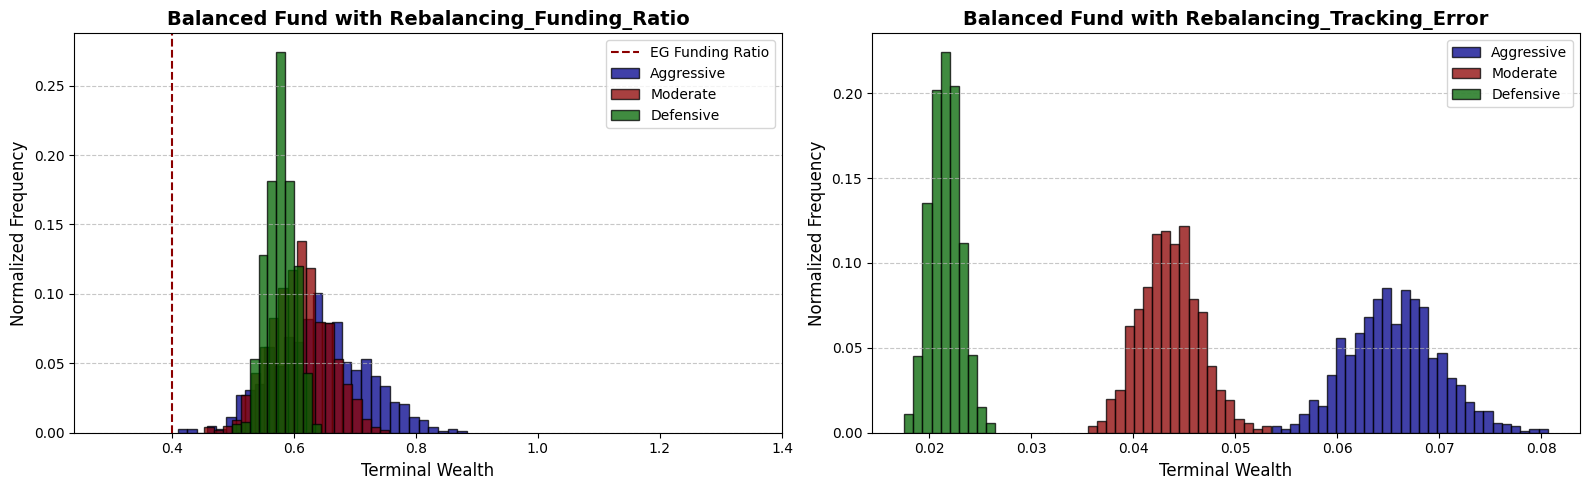

In [34]:
fund_allocation_simulator.draw_funding_ratio_distributions("Balanced Fund with Rebalancing",
                                                          aspirational_funding_ratio_bnh0_1,
                                                          aspirational_funding_ratio_bnh0_2,
                                                          aspirational_funding_ratio_bnh0_3,
                                                          tracking_error_bnh0_1,
                                                          tracking_error_bnh0_2,
                                                          tracking_error_bnh0_3
                                                          )

Balanced fund is different 

## Balanced Fund with Incorrect safe asset

In [35]:
_, _, _,  aspirational_funding_ratio_bnh0_1, tracking_error_bnh0_1 = fund_allocation_simulator.balanced_fund(psp_returns = simulated_market.S_p.pct_change(),
                                                                                ghp_returns = simulated_market.B_p.pct_change(),
                                                                                x = 0.1,
                                                                                rebalance_each_X_periods = 21,
                                                                                name = 'Balanced_Fund_x_0.1_rebalancing_21_Constant_Maturity',
                                                                                periods_per_year = int(N/T))

_, _, _,  aspirational_funding_ratio_bnh0_2, tracking_error_bnh0_2 =fund_allocation_simulator.balanced_fund(psp_returns = simulated_market.S_p.pct_change(),
                                                                                ghp_returns = simulated_market.B_p.pct_change(),
                                                                                x = 0.2,
                                                                                rebalance_each_X_periods = 21,
                                                                                name = 'Balanced_Fund_x_0.2_rebalancing_21_Constant_Maturity',
                                                                                periods_per_year = int(N/T))

_, _, _,  aspirational_funding_ratio_bnh0_3, tracking_error_bnh0_3= fund_allocation_simulator.balanced_fund(psp_returns = simulated_market.S_p.pct_change(),
                                                                                ghp_returns = simulated_market.B_p.pct_change(),
                                                                                x = 0.3,
                                                                                rebalance_each_X_periods = 21,
                                                                                name = 'Balanced_Fund_x_0.3_rebalancing_21_Constant_Maturity',
                                                                                periods_per_year = int(N/T))

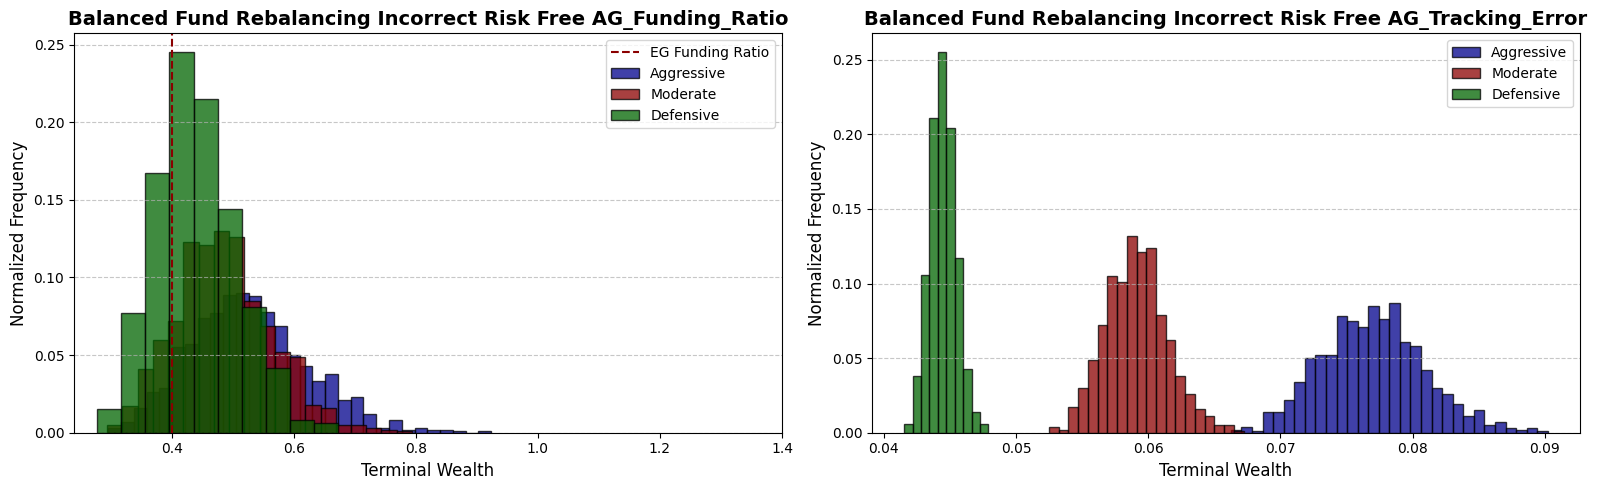

In [36]:
fund_allocation_simulator.draw_funding_ratio_distributions("Balanced Fund Rebalancing Incorrect Risk Free AG",
                                                          aspirational_funding_ratio_bnh0_1,
                                                          aspirational_funding_ratio_bnh0_2,
                                                          aspirational_funding_ratio_bnh0_3,
                                                          tracking_error_bnh0_1,
                                                          tracking_error_bnh0_2,
                                                          tracking_error_bnh0_3
                                                          )

## CPPI Fund with Correct Safe Asset

In [37]:
portfolio_m3 = fund_allocation_simulator.run_cppi(psp_returns = simulated_market.S_p.pct_change().fillna(0),
                                                 floor = simulated_market.retirement_bond_essential_p,
                                                 ghp_returns = simulated_market.retirement_bond_essential_p.pct_change().fillna(0),
                                                 initial_investment=287000,
                                                 m=3,
                                                 n_jobs=-1)

portfolio_m4 = fund_allocation_simulator.run_cppi(psp_returns = simulated_market.S_p.pct_change().fillna(0),
                                                 floor = simulated_market.retirement_bond_essential_p,
                                                 ghp_returns = simulated_market.retirement_bond_essential_p.pct_change().fillna(0),
                                                 initial_investment=287000,
                                                 m=4,
                                                 n_jobs=-1)

portfolio_m5 = fund_allocation_simulator.run_cppi(psp_returns = simulated_market.S_p.pct_change().fillna(0),
                                                 floor = simulated_market.retirement_bond_essential_p,
                                                 ghp_returns = simulated_market.retirement_bond_essential_p.pct_change().fillna(0),
                                                 initial_investment=287000,
                                                 m=5,
                                                 n_jobs=-1)

Running CPPI simulations in parallel...


Simulating Paths: 100%|█████████████████████| 1000/1000 [01:22<00:00, 12.08it/s]


Running CPPI simulations in parallel...


Simulating Paths: 100%|█████████████████████| 1000/1000 [01:25<00:00, 11.70it/s]


Running CPPI simulations in parallel...


Simulating Paths: 100%|█████████████████████| 1000/1000 [01:48<00:00,  9.18it/s]


In [38]:
aspirational_funding_ratio_m3, tracking_error_m3 = fund_allocation_simulator.add_entry_to_results_dataframe('CPPI_m_3',
                                                                 portfolio_m3.pct_change().fillna(0),
                                                                 periods_per_year = 252)
aspirational_funding_ratio_m4, tracking_error_m4 = fund_allocation_simulator.add_entry_to_results_dataframe('CPPI_m_4',
                                                                 portfolio_m4.pct_change().fillna(0),
                                                                 periods_per_year = 252)
aspirational_funding_ratio_m5, tracking_error_m5 = fund_allocation_simulator.add_entry_to_results_dataframe('CPPI_m_5',
                                                                 portfolio_m5.pct_change().fillna(0),
                                                                 periods_per_year = 252)

## CPPI Fund with Incorrect safe asset

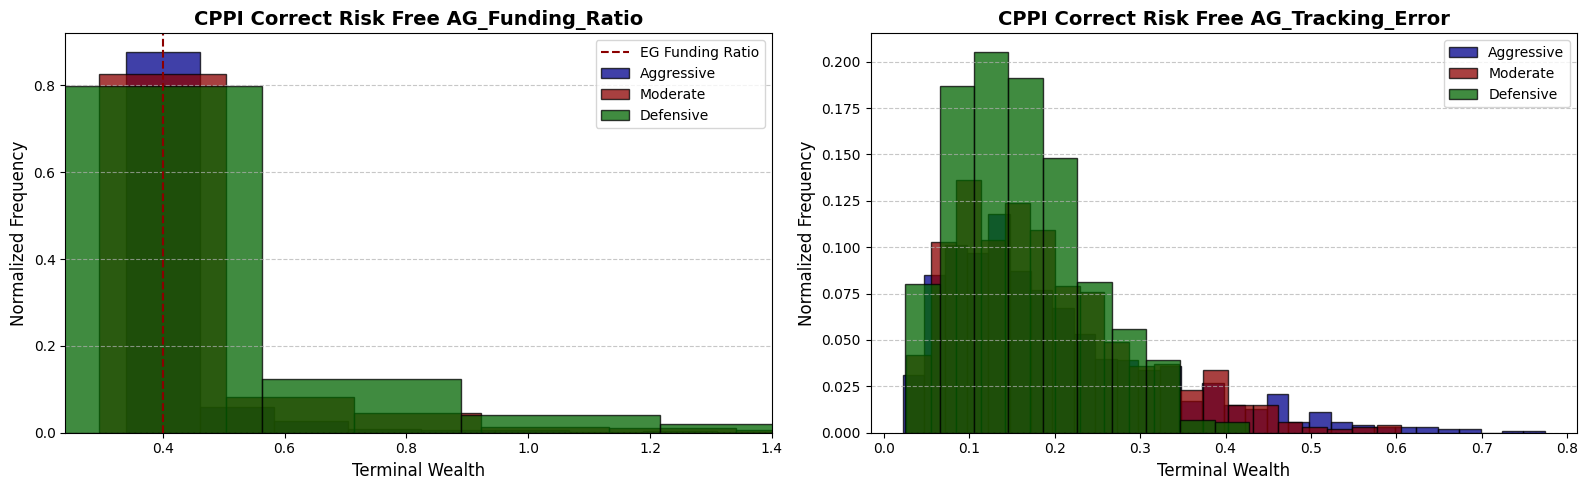

In [39]:
fund_allocation_simulator.draw_funding_ratio_distributions("CPPI Correct Risk Free AG",
                                                          aspirational_funding_ratio_m3,
                                                          aspirational_funding_ratio_m4,
                                                          aspirational_funding_ratio_m5,
                                                          tracking_error_m3,
                                                          tracking_error_m4,
                                                          tracking_error_m5
                                                          )

In [40]:
portfolio_m3 = fund_allocation_simulator.run_cppi(psp_returns = simulated_market.S_p.pct_change().fillna(0),
                                                 floor = simulated_market.retirement_bond_essential_p,
                                                 ghp_returns = simulated_market.B_p.pct_change().fillna(0),
                                                 initial_investment=287000,
                                                 m=3,
                                                 n_jobs=-1)

portfolio_m4 = fund_allocation_simulator.run_cppi(psp_returns = simulated_market.S_p.pct_change().fillna(0),
                                                 floor = simulated_market.retirement_bond_essential_p,
                                                 ghp_returns = simulated_market.B_p.pct_change().fillna(0),
                                                 initial_investment=287000,
                                                 m=4,
                                                 n_jobs=-1)

portfolio_m4 = fund_allocation_simulator.run_cppi(psp_returns = simulated_market.S_p.pct_change().fillna(0),
                                                 floor = simulated_market.retirement_bond_essential_p,
                                                 ghp_returns = simulated_market.B_p.pct_change().fillna(0),
                                                 initial_investment=287000,
                                                 m=5,
                                                 n_jobs=-1)

Running CPPI simulations in parallel...


Simulating Paths: 100%|█████████████████████| 1000/1000 [01:04<00:00, 15.39it/s]


Running CPPI simulations in parallel...


Simulating Paths: 100%|█████████████████████| 1000/1000 [00:58<00:00, 17.10it/s]


Running CPPI simulations in parallel...


Simulating Paths: 100%|█████████████████████| 1000/1000 [01:07<00:00, 14.80it/s]


In [41]:
aspirational_funding_ratio_m3, tracking_error_m3 = fund_allocation_simulator.add_entry_to_results_dataframe('CPPI_m_3_rf_incorrect',
                                                                 portfolio_m3.pct_change().fillna(0),
                                                                 periods_per_year = 252)
aspirational_funding_ratio_m4, tracking_error_m4 = fund_allocation_simulator.add_entry_to_results_dataframe('CPPI_m_4_rf_incorrect',
                                                                 portfolio_m4.pct_change().fillna(0),
                                                                 periods_per_year = 252)
aspirational_funding_ratio_m5, tracking_error_m5 = fund_allocation_simulator.add_entry_to_results_dataframe('CPPI_m_5_rf_incorrect',
                                                                 portfolio_m5.pct_change().fillna(0),
                                                                 periods_per_year = 252)

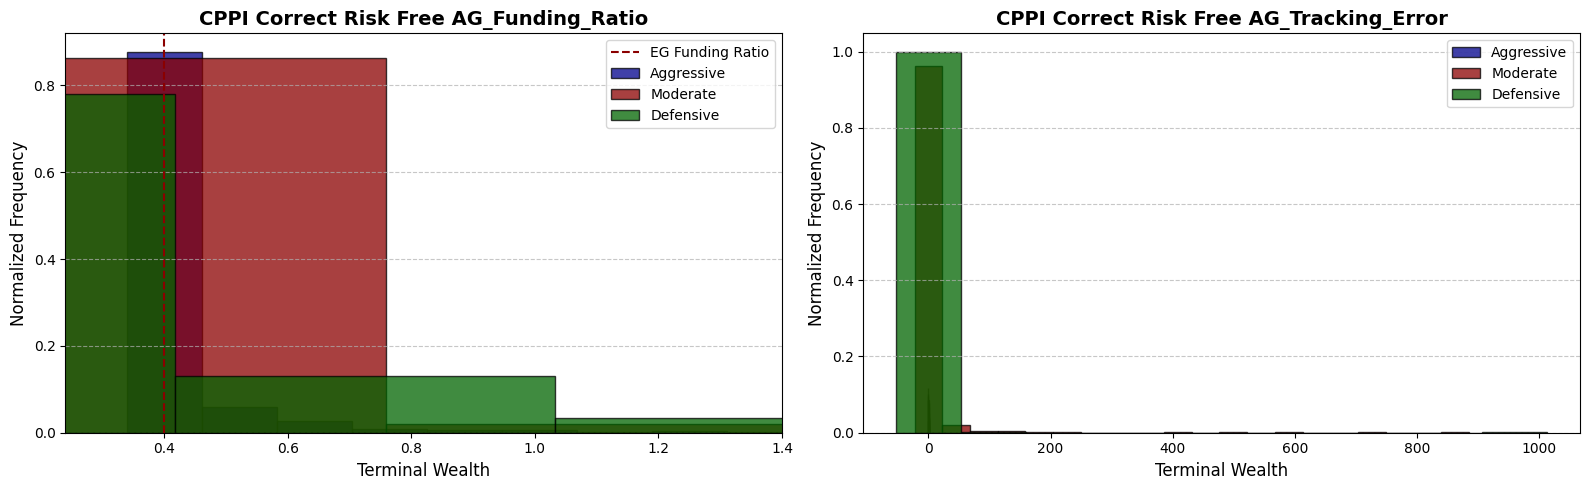

In [42]:
fund_allocation_simulator.draw_funding_ratio_distributions("CPPI Correct Risk Free AG",
                                                          aspirational_funding_ratio_m3,
                                                          aspirational_funding_ratio_m4,
                                                          aspirational_funding_ratio_m5,
                                                          tracking_error_m3,
                                                          tracking_error_m4,
                                                          tracking_error_m5
                                                          )

In [49]:
fund_allocation_simulator.results_df.sort_values(by = 'Average_Funding_Ratio_AG', ascending = False).sort_values(by = 'Average_Funding_Ratio_AG', ascending = False)#.to_csv('table.csv')

,Probability_Reach_AG,Average_Funding_Ratio_AG,Std_Funding_Ratio_AG,Probability_Reach_EG,Average_Funding_Ratio_EG,Average_Max Drawdown,Average_Tracking_Error,Breaches_of_EG_per_year,Average_Utility_funding_ratio
Balanced_Fund_x_0.3_rebalancing_21,0.0,0.65,0.077,1.0,1.624,-0.225,0.066,0.002143,0.649664
Buy_and_Hold_x_0.3_rebalancing_none,0.004,0.642,0.103,1.0,1.604,-0.274,0.074,0.000000,0.641470
Buy_and_Hold_Best,0.002,0.634,0.095,1.0,1.586,-0.253,0.068,0.000000,0.634329
CPPI_m_3,0.092,0.622,0.332,1.0,1.555,-1.004,0.181,0.000000,0.581395
Balanced_Fund_x_0.2_rebalancing_21,0.0,0.617,0.049,1.0,1.543,-0.16,0.044,0.000000,0.617352
Buy_and_Hold_x_0.2_rebalancing_none,0.0,0.612,0.069,1.0,1.53,-0.191,0.051,0.000000,0.611831
Balanced_Fund_x_0.1_rebalancing_21,0.0,0.585,0.023,1.0,1.462,-0.125,0.022,0.000000,0.584779
Buy_and_Hold_x_0.1_rebalancing_none,0.0,0.582,0.034,1.0,1.455,-0.133,0.026,0.000000,0.581990
CPPI_m_3_rf_incorrect,0.106,0.559,0.445,0.622,1.398,-1.146,2.128,1.690702,-inf
CPPI_m_4,0.052,0.541,0.325,1.0,1.352,-1.274,0.205,0.000000,0.508565


Test different asset allocation strategies based on prices simulated by stochastic processes with sharpe ratio that the PSP chosen by us had and compare them.
What strategies:\

•⁠  ⁠buy and hold stock + retirement bond across x = 0.1,0.2,0.3\
•⁠  ⁠⁠buy and hold stock + constant maturity bond across x = 0.1,0.2,0.3\
•⁠  ⁠⁠fixed mix (balanced fund) stock + retirement bond across x = 0.1,0.2,0.3\
•⁠  ⁠⁠fixed mix (balanced fund) stock + constant maturity bond across x = 0.1,0.2,0.3\
•⁠  ⁠⁠CPPI fund on stock with different parameters m\
•⁠  ⁠⁠Target volatility fund stock + retirement bond\
•⁠  ⁠⁠ Target volatility fund stock + constant maturity bond

Rebalancing of funds is done at monthly level

These strategies should be compared by:\
•⁠  ⁠tracking error (plot histograms for each strategy + save average tracking error and standard deviation in the table)\
•⁠  ⁠⁠Funding ratio of aspirational goal AT/LT (plot histograms + save average value and standard deviation to table)\
•⁠  ⁠⁠Funding ratio of essential goal AT/LT (plot histograms + save average value and stadard deviation to table and 0.01% quantile of essential goal to table)\
•⁠  ⁠⁠Max drawdown (save in table)\
•⁠  Days Essential Goal Was violated
